In [1]:
import os
import shutil
import tempfile
import time
import glob

from torch.utils.tensorboard import SummaryWriter
from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.nn.functional as F
from monai import transforms
from monai.apps import MedNISTDataset
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, SmartCacheDataset
from monai.utils import first, set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random

import pandas as pd

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler

from monai.metrics import compute_iou

#print_config()

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
set_determinism(0)

## Using Final_ADC_Dataset

3D ADC volumes (225,225,225)

In [8]:
IMAGE_SIZE = 225

In [9]:
train_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])

val_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/val.csv")
val_images_path = []

with open(val_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        val_images_path.append(ROOT_DIR+line[0])

test_reconstruction_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/Final_ADC_dataset/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        test_reconstruction_images_path.append(ROOT_DIR+line[0])


1636it [00:00, 343162.70it/s]


204it [00:00, 112583.95it/s]
205it [00:00, 155008.53it/s]


In [10]:
#train_datalist = sorted(train_images_path)
train_datalist = train_images_path

#val_datalist = sorted(val_images_path)
val_datalist = val_images_path

#val_datalist = sorted(val_images_path)
test_reconstruction_datalist = test_reconstruction_images_path


batch_size = 1
num_workers = 4


In [11]:
class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data

In [ ]:

train_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.RandAffine(prob=0.2, rotate_range=(0.10, 0.10, 0.10), lazy=True),#+- 0.15 radians for each axis
        transforms.RandScaleCrop(roi_scale=0.9, max_roi_scale=1.1, random_size=True, lazy=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE), lazy=True),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.RandScaleIntensity(factors=0.15),
        SetBackgroundToZero()
    ]
)
train_ds = CacheDataset(data=train_datalist, transform=train_transforms)
""" train_ds = SmartCacheDataset(
    data=train_datalist,
    transform=train_transforms,
    cache_num=600,
    replace_rate=0.5,  # Adjust the replacement rate as needed
) 
train_ds.start()  # Must call this to enable smart caching
"""

train_loader = DataLoader(
    #collate_fn=pad_list_data_collate: any tensors are centrally padded to match the shape of the biggest tensor in each dimension
    train_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True, collate_fn=pad_list_data_collate
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1636/1636 [08:03<00:00,  3.39it/s]


' train_ds = SmartCacheDataset(\n    data=train_datalist,\n    transform=train_transforms,\n    cache_num=600,\n    replace_rate=0.5,  # Adjust the replacement rate as needed\n) \ntrain_ds.start()  # Must call this to enable smart caching\n'



        Initialize SmartCacheDataset object and cache for the first epoch.

        Call start() to run replacement thread in background.

        Call update_cache() before every epoch to replace training items.

        Call shutdown() when training ends.



In [14]:

val_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE)),
        SetBackgroundToZero()
    ]
)
val_ds = CacheDataset(data=val_datalist, transform=val_transforms)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204/204 [01:39<00:00,  2.04it/s]


In [15]:
"""

test_reconstruction_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE)),
        SetBackgroundToZero()
    ]
)
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_reconstruction_transforms)
test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)
"""

'\n\ntest_reconstruction_transforms = transforms.Compose(\n    [\n        transforms.LoadImage(),\n        transforms.EnsureChannelFirst(),\n        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),\n        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE)),\n        SetBackgroundToZero()\n    ]\n)\ntest_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_reconstruction_transforms)\ntest_reconstruction_loader = DataLoader(\n    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True\n)\n'

### Visualisation of the training images

/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/Final_ADC_Dataset/HCP-YA_registered/200210.nii.gz


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

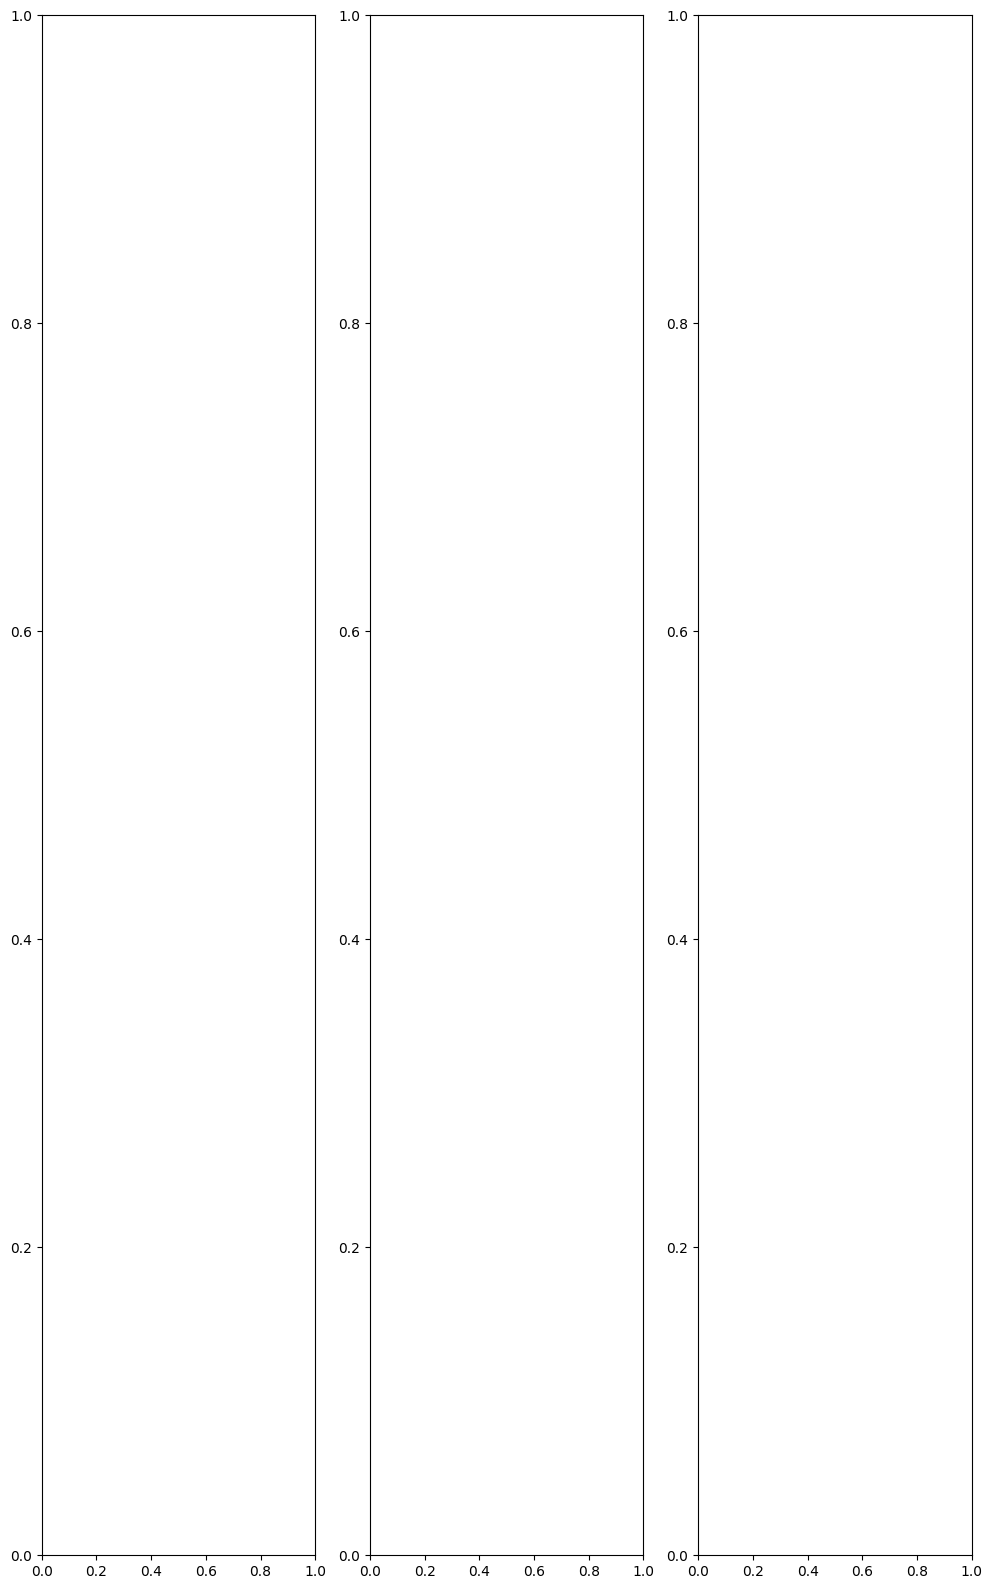

In [12]:

for i, batch in enumerate(train_loader):
    if i == 1:
        #print(f"batch shape: {batch.shape}")
        fig, axes = plt.subplots(batch_size, 3, figsize=(12, 20))
        for idx in range(batch_size):
            
            image = batch[idx, 0].cpu().numpy()
            print(f"{train_datalist[idx]}")

            axial_slice = image[image.shape[0] // 2, :, :]
            sagittal_slice = image[:, image.shape[1] // 2, :]
            coronal_slice = image[:, :, image.shape[2] // 2]

            axes[idx, 0].imshow(axial_slice, cmap="gray", vmin=0, vmax=1)
            axes[idx, 0].set_title(f"Image {idx+1} - Sagittal")
            axes[idx, 0].axis("off")

            axes[idx, 1].imshow(sagittal_slice, cmap="gray", vmin=0, vmax=1)
            axes[idx, 1].set_title(f"Image {idx+1} - Coronal")
            axes[idx, 1].axis("off")

            axes[idx, 2].imshow(coronal_slice, cmap="gray", vmin=0, vmax=1)
            axes[idx, 2].set_title(f"Image {idx+1} - Axial")
            axes[idx, 2].axis("off")

        plt.tight_layout()
        plt.show()
        break


### Define network, scheduler, optimizer, and inferer
**!! Est ce qu'il vaut mieux que je prenne exactement le même modèle que dans les experiences en 2D ? (attention levels, scheduler etc)?**
We will use a DDPM in this example; for that, we need to define a `DiffusionModelUNet` network that will have as input the noisy images and the values for the timestep `t`, and it will predict the noise that is present in the image.

In this example, we have a network with three levels (with 256, 256, and 512 channels in each). In every level, we will have two residual blocks, and only the last one will have an attention block with a single attention head (with 512 channels).

In [17]:
DEVICE_TYPE = "cuda:0"

In [18]:
device = torch.device(DEVICE_TYPE)

model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=[64, 128, 128],
    attention_levels=[False, True, True], 
    num_head_channels=[0, 128, 128], 
    num_res_blocks=2, 
).to(device)

num_train_timesteps = 1000

scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)

Together with our U-net, we need to define the Noise Scheduler for the diffusion model. This scheduler is responsible for defining the amount of noise that should be added in each timestep `t` of the diffusion model's Markov chain. Besides that, it has the operations to perform the reverse process, which will remove the noise of the images (a.k.a. denoising process). In this case, we are using a `DDPMScheduler`. Here we are using 1000 timesteps and a `scaled_linear` profile for the beta values (proposed in [Rombach et al. "High-Resolution Image Synthesis with Latent Diffusion Models"](https://arxiv.org/abs/2112.10752)). This profile had better results than the `linear, proposed in the original DDPM's paper. In `beta_start` and `beta_end`, we define the limits for the beta values. These are important to determine how accentuated is the addition of noise in the image.

### Model training

In [19]:
writer = SummaryWriter(ROOT_DIR+"Code/Tensorboard/Experiment_4_1_ADC_3d_ddpm")

max_epochs = 10000
val_interval = 3
epoch_loss_list = []
val_epoch_loss_list = []

best_val_epoch_loss = np.inf
best_val_epoch = 0

scaler = GradScaler(DEVICE_TYPE)
total_start = time.time()
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=70)
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in progress_bar:
        images = batch.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE_TYPE, enabled=True):
            # Generate random noise
            noise = torch.randn_like(images).to(device)
            #noise = generate_simplex_noise(simplexObj, images.shape).to(device)

            # Create timesteps
            timesteps = torch.randint(0, num_train_timesteps, (images.shape[0],), device=images.device).long()

            # Get model prediction
            noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)

            loss = F.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

        epoch_len = len(train_ds)
        

        progress_bar.set_postfix({"loss": epoch_loss / (step + 1)})

    epoch_loss_list.append(epoch_loss / (step + 1))
    writer.add_scalar("train_loss", epoch_loss / (step + 1), epoch)

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_epoch_loss = 0
        for step, batch in enumerate(val_loader):
            images = batch.to(device)
            with torch.no_grad(), autocast(device_type=DEVICE_TYPE, enabled=True):
                noise = torch.randn_like(images).to(device)
                #noise = generate_simplex_noise(simplexObj, shape=images.shape).to(device)

                timesteps = torch.randint(0, num_train_timesteps, (images.shape[0],), device=images.device).long()
                noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
                val_loss = F.mse_loss(noise_pred.float(), noise.float())

            val_epoch_loss += val_loss.item()

            progress_bar.set_postfix({"val_loss": val_epoch_loss / (step + 1)})

        val_epoch_loss_list.append(val_epoch_loss / (step + 1))
        writer.add_scalar("val_loss", val_epoch_loss / (step + 1), epoch)   # moi

        if val_epoch_loss(step + 1) < best_val_epoch_loss/(step + 1):
            best_val_epoch_loss = val_epoch_loss/(step + 1)
            best_val_epoch = epoch + 1
            torch.save(
                model.state_dict(),
                os.path.join(ROOT_DIR+"AnoDiffExperiments/Best_models/3d_ddpm", "Experiment_4_1_ADC_3d_ddpm.pth"),
            )
            print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current val loss: {val_epoch_loss/(step + 1):.4f}"
                f"\nbest val loss: {best_val_epoch_loss/(step + 1):.4f}"
                f" at epoch: {best_val_epoch}"
            )
            writer.add_scalar("best_val_loss", best_val_epoch_loss/(step + 1), best_val_epoch)

            noise = torch.randn_like(images).to(device)
            noise = noise.to(device)
            scheduler.set_timesteps(num_inference_steps=1000)
            with autocast(device_type=DEVICE_TYPE, enabled=True):
                image = inferer.sample(input_noise=noise, diffusion_model=model, scheduler=scheduler)
            writer.add_image("sampled_image", image[0, 0].cpu().numpy(), global_step=epoch, dataformats="HW")
            #plt.figure(figsize=(2, 2))
            #plt.imshow(image[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
            #plt.tight_layout()
            #plt.axis("off")
            #plt.show()

total_time = time.time() - total_start
print(f"train completed, total time: {total_time}.")

Epoch 0:   0%|                               | 0/1636 [00:03<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 3877.94 GiB. GPU 0 has a total capacity of 93.10 GiB of which 53.72 GiB is free. Including non-PyTorch memory, this process has 39.37 GiB memory in use. Of the allocated memory 38.02 GiB is allocated by PyTorch, and 697.53 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)